In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets

violations2017 = pd.read_csv('/content/Parking_Violations_Issued_-_Fiscal_Year_2017.csv')
violations2018 = pd.read_csv('/content/Parking_Violations_Issued_-_Fiscal_Year_2018.csv')
violations2019 = pd.read_csv('/content/Parking_Violations_Issued_-_Fiscal_Year_2019.csv')
violations2020 = pd.read_csv('/content/Parking_Violations_Issued_-_Fiscal_Year_2020.csv')
descriptors = pd.read_csv('/content/ParkingViolationCodes_2020.csv')

# Keep relevant columns
columns = [
    'Issue Date',
    'Plate ID',
    'Violation Code',
    'Registration State',
    'Plate Type',
    'Vehicle Body Type',
    'Vehicle Make',
    'Issuing Agency',
    'Violation Time',
    'Vehicle Color',
    'Vehicle Year',
    'Violation County',
    'Street Name'
]

violations2017 = violations2017[columns]
violations2018 = violations2018[columns]
violations2019 = violations2019[columns]
violations2020 = violations2020[columns]

# Combine yearly datasets
all_violations = pd.concat(
    [violations2017, violations2018, violations2019, violations2020],
    ignore_index=True
)

# Convert Issue Date
all_violations['Issue Date'] = pd.to_datetime(
    all_violations['Issue Date'],
    errors='coerce'
)

# Remove rows missing core analysis fields
all_violations = all_violations.dropna(
    subset=['Issue Date', 'Violation Code', 'Violation Time', 'Violation County', 'Street Name']
)

# Clean invalid violation codes
all_violations = all_violations[all_violations['Violation Code'] != 0]

# Add date features
all_violations['Year'] = all_violations['Issue Date'].dt.year
all_violations['Month'] = all_violations['Issue Date'].dt.month
all_violations['Day of Week'] = all_violations['Issue Date'].dt.day_name()

# Clean borough names
borough_map = {
    'NY': 'Manhattan',
    'MN': 'Manhattan',
    'K': 'Brooklyn',
    'BK': 'Brooklyn',
    'KINGS': 'Brooklyn',
    'Q': 'Queens',
    'QN': 'Queens',
    'QNS': 'Queens',
    'BX': 'Bronx',
    'BRONX': 'Bronx',
    'R': 'Staten Island',
    'ST': 'Staten Island'
}

all_violations['Borough'] = all_violations['Violation County'].replace(borough_map)

all_violations = all_violations[
    all_violations['Borough'].isin(
        ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
    )
]

# Clean vehicle year without dropping rows
all_violations['Vehicle Year'] = all_violations['Vehicle Year'].replace(0, pd.NA)

# Convert violation time
def convert_violation_time(time_str):
    try:
        if pd.isna(time_str):
            return pd.NA

        time_str = str(time_str).strip().upper()

        if len(time_str) < 5:
            return pd.NA

        hour = int(time_str[:2])
        minute = int(time_str[2:4])
        period = time_str[-1]

        if hour < 1 or hour > 12 or minute < 0 or minute > 59:
            return pd.NA

        if period == 'P' and hour != 12:
            hour += 12
        elif period == 'A' and hour == 12:
            hour = 0
        elif period not in ['A', 'P']:
            return pd.NA

        return hour + minute / 60

    except:
        return pd.NA

all_violations['Violation Hour'] = all_violations['Violation Time'].apply(convert_violation_time)
all_violations = all_violations[all_violations['Violation Hour'].notna()]

# Merge violation descriptions and fine amounts
all_violations = all_violations.merge(
    descriptors,
    left_on='Violation Code',
    right_on='VIOLATION CODE',
    how='left'
)

all_violations = all_violations.drop(columns=['VIOLATION CODE'])

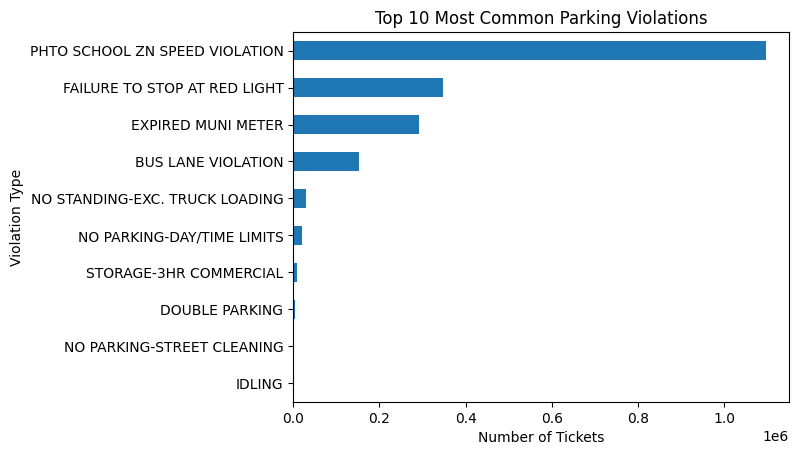

In [3]:
# 1. Most common violation types
all_violations['VIOLATION DESCRIPTION'].value_counts().head(10).plot(kind='barh')

plt.xlabel('Number of Tickets')
plt.ylabel('Violation Type')
plt.title('Top 10 Most Common Parking Violations')
plt.gca().invert_yaxis()
plt.show()


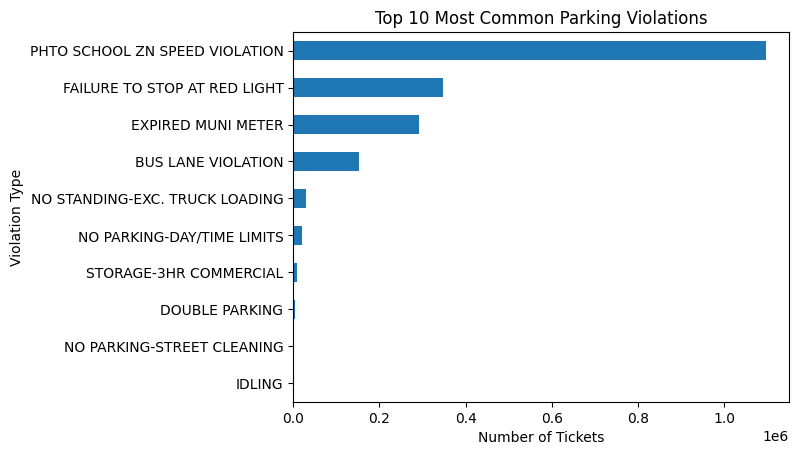

In [4]:
# 2. Tickets by borough
all_violations['VIOLATION DESCRIPTION'].value_counts().head(10).plot(kind='barh')

plt.xlabel('Number of Tickets')
plt.ylabel('Violation Type')
plt.title('Top 10 Most Common Parking Violations')
plt.gca().invert_yaxis()
plt.show()

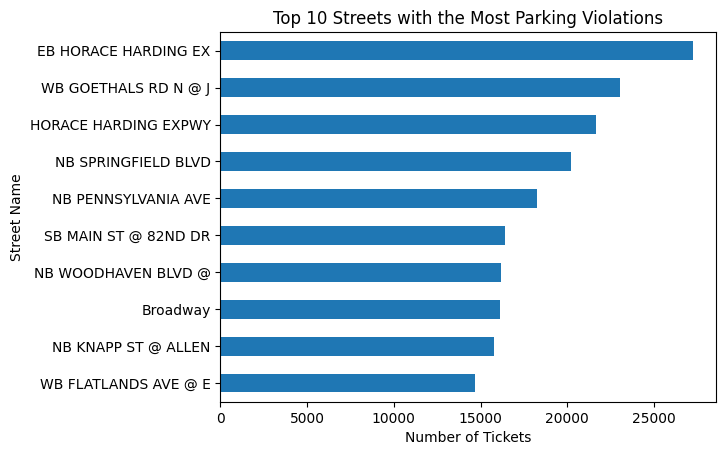

In [5]:
# 3. Top ticketed streets
all_violations['Street Name'].value_counts().head(10).plot(kind='barh')

plt.xlabel('Number of Tickets')
plt.ylabel('Street Name')
plt.title('Top 10 Streets with the Most Parking Violations')
plt.gca().invert_yaxis()
plt.show()

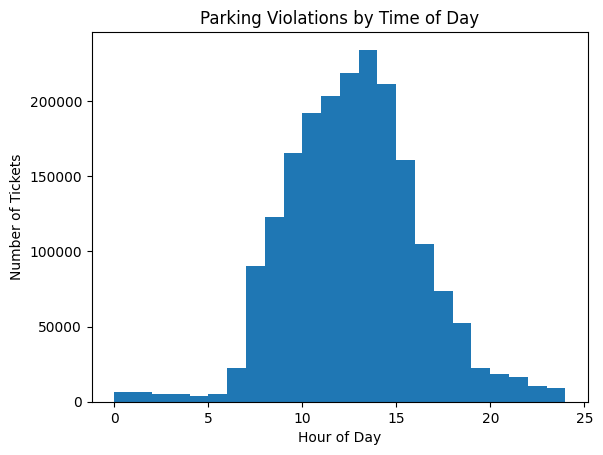

In [6]:
# 4. Tickets by hour of day
all_violations['Violation Hour'].plot(kind='hist', bins=24)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Tickets')
plt.title('Parking Violations by Time of Day')
plt.show()

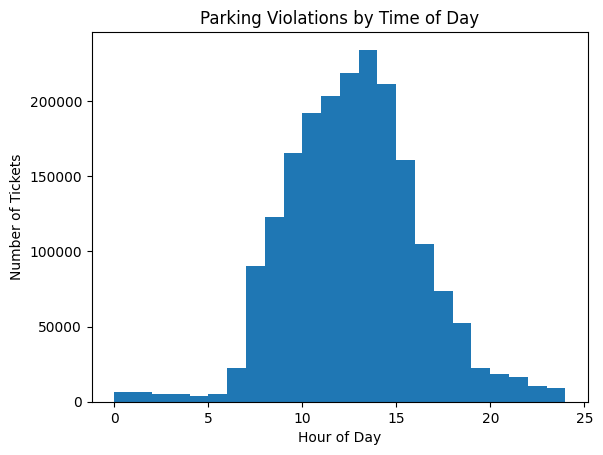

In [7]:
# 5. Tickets by month
all_violations['Violation Hour'].plot(kind='hist', bins=24)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Tickets')
plt.title('Parking Violations by Time of Day')
plt.show()

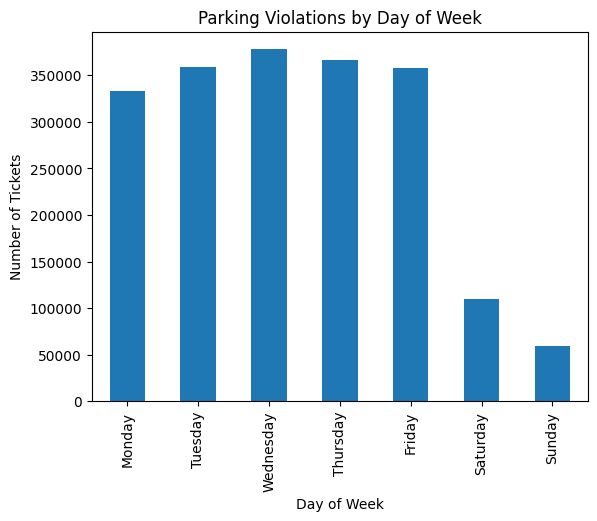

In [8]:
# 6. Tickets by day of week
day_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

all_violations['Day of Week'].value_counts().reindex(day_order).plot(kind='bar')

plt.xlabel('Day of Week')
plt.ylabel('Number of Tickets')
plt.title('Parking Violations by Day of Week')
plt.show()